## 1.Cargar el dataset

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/sivigila_vih.csv")

print("Dimensiones:", df.shape)

Dimensiones: (15470, 116)


C:\Users\Santiago\AppData\Local\Temp\ipykernel_24256\3071516417.py:4: DtypeWarning: Columns (0: cod_dpto_r, 1: fm_grado) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/sivigila_vih.csv")


In [4]:
print(df.columns.tolist())

['cod_eve', 'fec_not', 'semana', 'año', 'cod_pre', 'cod_sub', 'edad_', 'uni_med_', 'nacionali_', 'nombre_nacionalidad', 'sexo_', 'cod_pais_o', 'cod_dpto_o', 'cod_mun_o', 'area_', 'localidad_', 'cen_pobla_', 'vereda_', 'bar_ver_', 'ocupacion_', 'tip_ss_', 'cod_ase_', 'per_etn_', 'nom_grupo_', 'estrato_', 'gp_discapa', 'gp_desplaz', 'gp_migrant', 'gp_carcela', 'gp_gestan', 'sem_ges_', 'gp_indigen', 'gp_pobicbf', 'gp_mad_com', 'gp_desmovi', 'gp_psiquia', 'gp_vic_vio', 'gp_otros', 'fuente', 'cod_pais_r', 'cod_dpto_r', 'cod_mun_r', 'fec_con_', 'ini_sin_', 'tip_cas_', 'pac_hos_', 'fec_hos_', 'con_fin_', 'fec_def_', 'ajuste_', 'fecha_nto_', 'cer_def_', 'cbmte_', 'fec_aju_', 'fm_fuerza', 'fm_unidad', 'fm_grado', 'mec_pro_t', 'ide_genero', 'dono_sangr', 'tip_pru', 'fec_res', 'val_res', 'est_cli', 'can_eso', 'can_va', 'tub_pul', 'can_cer', 'tub_exp', 'coccidiodo', 'citomegalo', 'ren_cit', 'encefalopa', 'otras_micr', 'his_ext', 'iso_cro', 'erp_zos', 'his_dis', 'lin_bur', 'neu_pne', 'neu_rec', 'li

Se validará los datos de las columnas

In [5]:
candidatas = [
    "tip_cas_",
    "tip_pru",
    "val_res",
    "est_cli",
    "ajuste_",
    "cer_def_",
    "clasificación_final"
]

for columna in candidatas:
    print("\n" + "="*50)
    print(columna)
    print("Valores únicos:", df[columna].nunique(dropna=False))
    print(df[columna].value_counts(dropna=False).head(15))


tip_cas_
Valores únicos: 1
tip_cas_
3    15470
Name: count, dtype: int64

tip_pru
Valores únicos: 5
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64

val_res
Valores únicos: 1890
val_res
NaN         13378
40             36
10000000       27
20             18
12000          13
0               6
1               6
Reactiva        5
16              4
1000000         4
119             3
Positiva        3
100000          3
13000           3
22200           3
Name: count, dtype: int64

est_cli
Valores únicos: 4
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64

ajuste_
Valores únicos: 3
ajuste_
0    14271
7     1197
3        2
Name: count, dtype: int64

cer_def_
Valores únicos: 415
cer_def_
NaN            15056
705815072          1
70582939-2         1
2.30643E+13        1
717579459          1
723170100          1
716861835          1
71757771           1
70505370-4         1
705822202          1
707693642      

In [6]:
columnas = ["tip_pru", "val_res", "est_cli", "ajuste_", "cer_def_"]

for columna in columnas:
    print("\n" + "=" * 60)
    print(f"COLUMNA: {columna}")
    print(f"Valores únicos: {df[columna].nunique(dropna=False)}")
    print(df[columna].value_counts(dropna=False).head(10))


COLUMNA: tip_pru
Valores únicos: 5
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64

COLUMNA: val_res
Valores únicos: 1890
val_res
NaN         13378
40             36
10000000       27
20             18
12000          13
0               6
1               6
Reactiva        5
16              4
1000000         4
Name: count, dtype: int64

COLUMNA: est_cli
Valores únicos: 4
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64

COLUMNA: ajuste_
Valores únicos: 3
ajuste_
0    14271
7     1197
3        2
Name: count, dtype: int64

COLUMNA: cer_def_
Valores únicos: 415
cer_def_
NaN            15056
705815072          1
70582939-2         1
2.30643E+13        1
717579459          1
723170100          1
716861835          1
71757771           1
70505370-4         1
705822202          1
Name: count, dtype: int64


In [7]:
variables_clinicas = [
    "tub_pul",
    "can_cer",
    "tub_exp",
    "coccidiodo",
    "citomegalo",
    "ren_cit",
    "encefalopa",
    "otras_micr",
    "his_ext",
    "iso_cro",
    "erp_zos",
    "his_dis",
    "lin_bur",
    "neu_pne",
    "neu_rec",
    "lin_inm",
    "cri_cro",
    "cri_ext",
    "sar_kap",
    "sin_ema",
    "leu_mul",
    "sep_rec",
    "tox_cer",
    "hep_b",
    "hep_c",
    "meningitis"
]

for columna in variables_clinicas:
    print(f"{columna:15} → {df[columna].value_counts(dropna=False).to_dict()}")

tub_pul         → {2.0: 15032, 1.0: 433, nan: 5}
can_cer         → {2.0: 15426, 1.0: 39, nan: 5}
tub_exp         → {2.0: 15331, 1.0: 134, nan: 5}
coccidiodo      → {2.0: 15458, 1.0: 7, nan: 5}
citomegalo      → {2.0: 15395, 1.0: 70, nan: 5}
ren_cit         → {2.0: 15447, 1.0: 18, nan: 5}
encefalopa      → {2.0: 15373, 1.0: 92, nan: 5}
otras_micr      → {2.0: 15234, 1.0: 227, nan: 9}
his_ext         → {2.0: 15435, 1.0: 30, nan: 5}
iso_cro         → {2.0: 15457, 1.0: 8, nan: 5}
erp_zos         → {2.0: 15416, 1.0: 49, nan: 5}
his_dis         → {2.0: 15430, 1.0: 35, nan: 5}
lin_bur         → {2.0: 15445, 1.0: 20, nan: 5}
neu_pne         → {2.0: 15335, 1.0: 130, nan: 5}
neu_rec         → {2.0: 15411, 1.0: 54, nan: 5}
lin_inm         → {2.0: 15434, 1.0: 31, nan: 5}
cri_cro         → {2.0: 15417, 1.0: 48, nan: 5}
cri_ext         → {2.0: 15398, 1.0: 67, nan: 5}
sar_kap         → {2.0: 15390, 1.0: 75, nan: 5}
sin_ema         → {2.0: 15259, 1.0: 206, nan: 5}
leu_mul         → {2.0: 15452, 1.0: 1

In [8]:
print("ESTADO CLÍNICO")
print(df["est_cli"].value_counts(dropna=False))

print("\nDONACIÓN DE SANGRE")
print(df["dono_sangr"].value_counts(dropna=False))

print("\nTIPO DE PRUEBA")
print(df["tip_pru"].value_counts(dropna=False))

ESTADO CLÍNICO
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64

DONACIÓN DE SANGRE
dono_sangr
2.0    13098
NaN     2217
1.0      155
Name: count, dtype: int64

TIPO DE PRUEBA
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64


In [9]:
candidatas_interesantes = [
    "tip_pru",
    "est_cli",
    "ajuste_",
    "cer_def_"
]

for col in candidatas_interesantes:
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    print("Valores únicos:", df[col].nunique(dropna=True))
    print("Valores nulos:", df[col].isna().sum())
    print("\nDistribución:")
    print(df[col].value_counts(dropna=False))


VARIABLE: tip_pru
Valores únicos: 4
Valores nulos: 5

Distribución:
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64

VARIABLE: est_cli
Valores únicos: 3
Valores nulos: 5

Distribución:
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64

VARIABLE: ajuste_
Valores únicos: 3
Valores nulos: 0

Distribución:
ajuste_
0    14271
7     1197
3        2
Name: count, dtype: int64

VARIABLE: cer_def_
Valores únicos: 414
Valores nulos: 15056

Distribución:
cer_def_
NaN               15056
705815072             1
70582939-2            1
2.30643E+13           1
717579459             1
                  ...  
714343133             1
22093020042282        1
716851059             1
705710096             1
717523414             1
Name: count, Length: 415, dtype: int64


In [10]:
for col in ["tip_pru", "est_cli", "ajuste_", "cer_def_"]:
    print(f"\n{'='*50}")
    print(f"VARIABLE: {col}")
    print(f"{'='*50}")
    
    print("Valores únicos:", df[col].nunique(dropna=True))
    print("Valores nulos:", df[col].isna().sum())
    print("\nPrimeros 15 valores más frecuentes:")
    print(df[col].value_counts(dropna=False).head(15))
    print("Porcentaje nulos:", round(df[col].isna().mean() * 100, 2), "%")
    print("Tipo:", df[col].dtype)


VARIABLE: tip_pru
Valores únicos: 4
Valores nulos: 5

Primeros 15 valores más frecuentes:
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64
Porcentaje nulos: 0.03 %
Tipo: float64

VARIABLE: est_cli
Valores únicos: 3
Valores nulos: 5

Primeros 15 valores más frecuentes:
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64
Porcentaje nulos: 0.03 %
Tipo: float64

VARIABLE: ajuste_
Valores únicos: 3
Valores nulos: 0

Primeros 15 valores más frecuentes:
ajuste_
0    14271
7     1197
3        2
Name: count, dtype: int64
Porcentaje nulos: 0.0 %
Tipo: int64

VARIABLE: cer_def_
Valores únicos: 414
Valores nulos: 15056

Primeros 15 valores más frecuentes:
cer_def_
NaN            15056
705815072          1
70582939-2         1
2.30643E+13        1
717579459          1
723170100          1
716861835          1
71757771           1
70505370-4         1
705822202          1
707693642          1
705235781          1
7169022

In [11]:
candidatas = [
    "tip_cas_",
    "tip_pru",
    "val_res",
    "est_cli",
    "ajuste_",
    "cer_def_",
    "clasificación_final"
]

resumen = []

for col in candidatas:
    resumen.append({
        "variable": col,
        "tipo": str(df[col].dtype),
        "valores_unicos": df[col].nunique(dropna=True),
        "nulos": df[col].isna().sum(),
        "porcentaje_nulos": round(df[col].isna().mean() * 100, 2)
    })

resumen_df = pd.DataFrame(resumen)

resumen_df

,variable,tipo,valores_unicos,nulos,porcentaje_nulos
0,tip_cas_,int64,1,0,0.00
1,tip_pru,float64,4,5,0.03
2,val_res,str,1889,13378,86.48
3,est_cli,float64,3,5,0.03
4,ajuste_,int64,3,0,0.00
5,cer_def_,str,414,15056,97.32
6,clasificación_final,int64,1,0,0.00


In [12]:
for col in ["tip_pru", "est_cli", "ajuste_"]:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False))


tip_pru
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
NaN       5
Name: count, dtype: int64

est_cli
est_cli
1.0    13845
2.0     1340
3.0      280
NaN        5
Name: count, dtype: int64

ajuste_
ajuste_
0    14271
7     1197
3        2
Name: count, dtype: int64


In [13]:
print(df[["tip_pru", "est_cli", "ajuste_"]].head(20).to_string())

    tip_pru  est_cli  ajuste_
0       2.0      1.0        0
1       4.0      1.0        0
2       3.0      1.0        0
3       4.0      1.0        0
4       2.0      1.0        0
5       1.0      2.0        7
6       2.0      1.0        0
7       4.0      1.0        0
8       2.0      1.0        0
9       4.0      1.0        0
10      3.0      1.0        0
11      4.0      1.0        7
12      3.0      1.0        0
13      4.0      1.0        0
14      3.0      1.0        0
15      2.0      1.0        0
16      2.0      1.0        0
17      1.0      1.0        0
18      3.0      1.0        0
19      1.0      1.0        0


In [14]:
print(df[[
    "tip_pru",
    "val_res",
    "est_cli",
    "ajuste_",
    "cer_def_",
    "fec_con_",
    "fec_res",
    "ini_sin_"
]].head(30).to_string())

    tip_pru val_res  est_cli  ajuste_ cer_def_    fec_con_     fec_res    ini_sin_
0       2.0   25015      1.0        0      NaN   4/01/2022  14/01/2022  16/12/2021
1       4.0     NaN      1.0        0      NaN  24/02/2021  24/02/2021  24/02/2021
2       3.0     NaN      1.0        0      NaN   9/02/2023  11/02/2023   1/12/2022
3       4.0     NaN      1.0        0      NaN   8/07/2020  10/07/2020   8/07/2020
4       2.0  211455      1.0        0      NaN   1/08/2014   3/09/2014  15/07/2014
5       1.0     NaN      2.0        7      NaN  14/03/2014  19/03/2014   7/03/2014
6       2.0  174000      1.0        0      NaN  31/10/2016   2/11/2016  27/10/2016
7       4.0     NaN      1.0        0      NaN  24/01/2023  26/11/2022  24/01/2023
8       2.0   36520      1.0        0      NaN  13/11/2019  26/11/2019  10/11/2019
9       4.0     NaN      1.0        0      NaN  21/02/2018  23/02/2018       -   -
10      3.0     NaN      1.0        0      NaN  21/03/2023  11/03/2023   1/03/2023
11  

In [15]:
print(df[["tip_pru", "est_cli", "ajuste_"]].corr(numeric_only=True))

          tip_pru   est_cli   ajuste_
tip_pru  1.000000 -0.155998 -0.021390
est_cli -0.155998  1.000000  0.122573
ajuste_ -0.021390  0.122573  1.000000


In [16]:
# Variable objetivo
target = "tip_pru"

# Eliminamos los registros donde no conocemos el tipo de prueba
df_model = df.dropna(subset=[target]).copy()

print("Registros para el modelo:", len(df_model))
print("\nDistribución del target:")
print(df_model[target].value_counts())

Registros para el modelo: 15465

Distribución del target:
tip_pru
4.0    5920
1.0    4883
3.0    2582
2.0    2080
Name: count, dtype: int64


In [17]:
features = [
    "edad_",
    "sexo_",
    "area_",
    "tip_ss_",
    "estrato_",
    "gp_discapa",
    "gp_desplaz",
    "gp_migrant",
    "gp_carcela",
    "gp_gestan",
    "gp_indigen",
    "gp_pobicbf",
    "gp_mad_com",
    "gp_desmovi",
    "gp_psiquia",
    "gp_vic_vio",
    "grupo_edad_ciclo",
    "periodo_epid",
    "mes_caso"
]

X = df_model[features].copy()
y = df_model[target].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (15465, 19)
Dimensiones de y: (15465,)


In [18]:
train_mask = df_model["año"] <= 2020
test_mask = df_model["año"] >= 2021

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

print("\nDistribución del target - entrenamiento:")
print(y_train.value_counts())

print("\nDistribución del target - prueba:")
print(y_test.value_counts())

Datos de entrenamiento: (10798, 19)
Datos de prueba: (4667, 19)

Distribución del target - entrenamiento:
tip_pru
1.0    4551
4.0    3535
2.0    1442
3.0    1270
Name: count, dtype: int64

Distribución del target - prueba:
tip_pru
4.0    2385
3.0    1312
2.0     638
1.0     332
Name: count, dtype: int64


In [21]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 4.6 MB/s eta 0:00:02
   --------------------------- ------------ 5.8/8.3 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 17.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Santiago\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "edad_",
    "estrato_",
    "periodo_epid",
    "mes_caso"
]

categorical_features = [
    "sexo_",
    "area_",
    "tip_ss_",
    "gp_discapa",
    "gp_desplaz",
    "gp_migrant",
    "gp_carcela",
    "gp_gestan",
    "gp_indigen",
    "gp_pobicbf",
    "gp_mad_com",
    "gp_desmovi",
    "gp_psiquia",
    "gp_vic_vio",
    "grupo_edad_ciclo"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Modificar el entrenamiento del modelo

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance"
    ))
])

knn_model.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [21]:
y_pred = knn_model.predict(X_test)

print("Primeras 20 predicciones:")
print(y_pred[:20])

Primeras 20 predicciones:
[1. 2. 4. 1. 4. 4. 3. 4. 2. 2. 4. 1. 1. 4. 1. 2. 1. 4. 4. 1.]


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.34

Reporte de clasificación:
              precision    recall  f1-score   support

         1.0       0.08      0.36      0.13       332
         2.0       0.16      0.11      0.13       638
         3.0       0.49      0.30      0.37      1312
         4.0       0.54      0.42      0.47      2385

    accuracy                           0.34      4667
   macro avg       0.32      0.30      0.28      4667
weighted avg       0.44      0.34      0.37      4667



In [23]:
resultados = []

for k in [3, 5, 7, 9, 11, 15, 20, 25, 30]:
    modelo = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=k,
            weights="distance"
        ))
    ])
    
    modelo.fit(X_train, y_train)
    
    predicciones = modelo.predict(X_test)
    
    accuracy_k = accuracy_score(y_test, predicciones)
    
    resultados.append({
        "k": k,
        "accuracy": accuracy_k
    })

resultados_df = pd.DataFrame(resultados)

print(resultados_df)

    k  accuracy
0   3  0.318192
1   5  0.331691
2   7  0.334476
3   9  0.339190
4  11  0.336833
5  15  0.340047
6  20  0.344975
7  25  0.345832
8  30  0.342190


In [24]:
mejor_k = resultados_df.loc[
    resultados_df["accuracy"].idxmax(),
    "k"
]

mejor_accuracy = resultados_df["accuracy"].max()

print("Mejor K:", int(mejor_k))
print("Mejor accuracy:", round(mejor_accuracy, 4))

Mejor K: 25
Mejor accuracy: 0.3458


Entrenamiento del modelo final

In [25]:
modelo_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=int(mejor_k),
        weights="distance"
    ))
])

modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


In [26]:
print("Accuracy final:", round(
    accuracy_score(y_test, y_pred_final), 4
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_final))

Accuracy final: 0.3458

Reporte de clasificación:
              precision    recall  f1-score   support

         1.0       0.08      0.37      0.13       332
         2.0       0.15      0.10      0.12       638
         3.0       0.51      0.30      0.38      1312
         4.0       0.55      0.43      0.48      2385

    accuracy                           0.35      4667
   macro avg       0.32      0.30      0.28      4667
weighted avg       0.45      0.35      0.38      4667



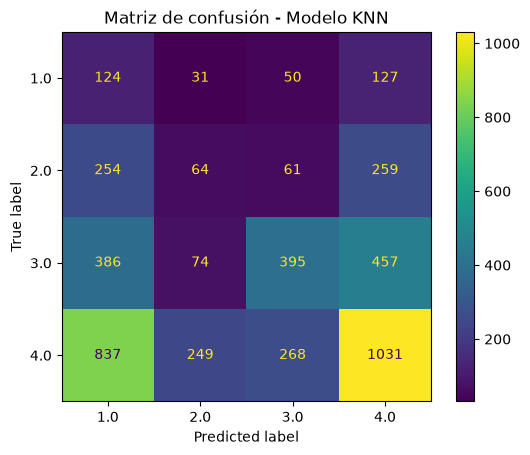

In [27]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo_final.classes_
)

disp.plot()

plt.title("Matriz de confusión - Modelo KNN")
plt.show()

In [28]:
print("=== RESULTADOS DEL MODELO FINAL ===")
print(f"Algoritmo: K-Nearest Neighbors (KNN)")
print(f"Mejor K: {int(mejor_k)}")
print(f"Accuracy: {mejor_accuracy:.4f}")
print(f"Accuracy (%): {mejor_accuracy * 100:.2f}%")

=== RESULTADOS DEL MODELO FINAL ===
Algoritmo: K-Nearest Neighbors (KNN)
Mejor K: 25
Accuracy: 0.3458
Accuracy (%): 34.58%


## Conclusiones

Se desarrolló un modelo de clasificación multiclase utilizando el algoritmo K-Nearest Neighbors (KNN), con el objetivo de predecir la categoría registrada en la variable `tip_pru`.

Para el modelo se utilizaron variables principalmente sociodemográficas y epidemiológicas, como edad, sexo, área, régimen de seguridad social, estrato y diferentes condiciones o características poblacionales. Se excluyeron variables relacionadas directamente con resultados posteriores del proceso para reducir el riesgo de fuga de información.

Los datos fueron divididos temporalmente, utilizando los registros de los años 2012 a 2020 para el entrenamiento y los registros de 2021 a 2023 para la evaluación. Esta división permitió evaluar el comportamiento del modelo sobre datos correspondientes a un periodo posterior al utilizado durante el entrenamiento.

Se evaluaron diferentes valores de K: 3, 5, 7, 9, 11, 15, 20, 25 y 30. El mejor resultado se obtuvo con K = 25, alcanzando un accuracy de 34.58% sobre el conjunto de prueba.

El reporte de clasificación mostró diferencias en el desempeño entre las cuatro categorías. La clase 4 obtuvo el mejor F1-score, con 0.48, mientras que las clases 1 y 2 presentaron mayores dificultades de clasificación, con F1-scores de 0.13 y 0.12 respectivamente.

En general, los resultados indican que las variables seleccionadas presentan una capacidad limitada para predecir correctamente las categorías de `tip_pru` utilizando KNN. Además, se observó una diferencia importante en la distribución de las categorías entre los datos de entrenamiento y prueba, lo que puede afectar el desempeño del modelo al realizar una evaluación temporal.

La matriz de confusión permite observar los errores de clasificación entre las diferentes categorías y complementa las métricas obtenidas durante la evaluación.